# Notebook 1: Implementación de DBSCAN con librerías

**Estudiantes:**  
Mateo Bermejo / Ronald Gómez / Adrián Murcia

**Fecha:** 26 / 05 / 26  
**Asignatura:** Inteligencia Artificial  
**Universidad:** Fundación Universitaria Los Libertadores  
**Entrega:** Entrega final - Modelo, aplicación y análisis

## 1. Introducción

En este notebook se implementa el algoritmo **DBSCAN** utilizando librerías de Python, principalmente **scikit-learn**, para resolver un problema de **segmentación de clientes para análisis de riesgo crediticio**.

El dataset utilizado corresponde a **Give Me Some Credit**, disponible en Kaggle. Este conjunto de datos contiene información histórica de clientes y variables asociadas al comportamiento financiero, como utilización de líneas de crédito, edad, retrasos en pagos, relación deuda-ingreso, ingreso mensual, número de créditos abiertos, préstamos inmobiliarios y dependientes.

El objetivo del proyecto no es mostrar únicamente que un cliente pertenece a un `Cluster 0`, `Cluster 1` o `Cluster 2`. El objetivo es traducir el resultado del clustering a una conclusión útil para un contexto financiero, por ejemplo:

- Cliente viable o de bajo riesgo.
- Cliente con riesgo moderado.
- Cliente de alto riesgo.
- Cliente atípico que requiere revisión manual.

DBSCAN es un algoritmo de aprendizaje no supervisado basado en densidad. Su objetivo es encontrar grupos de registros cercanos entre sí y detectar observaciones que no pertenecen claramente a ningún grupo, conocidas como **ruido** o **valores atípicos**.

En este proyecto, DBSCAN se usa para agrupar clientes con perfiles financieros similares y detectar clientes con comportamientos inusuales que podrían requerir un análisis adicional antes de tomar una decisión de negocio.

## 2. Fundamentos del algoritmo DBSCAN

DBSCAN significa **Density-Based Spatial Clustering of Applications with Noise**. Es un algoritmo de clustering que forma grupos según la densidad de puntos en el espacio de características.

DBSCAN trabaja principalmente con dos parámetros:

- **eps:** distancia máxima para considerar que dos puntos son vecinos.
- **min_samples:** cantidad mínima de puntos necesarios para formar una zona densa.

El algoritmo clasifica los puntos en tres tipos:

- **Punto núcleo:** tiene al menos `min_samples` vecinos dentro del radio `eps`.
- **Punto borde:** está cerca de un punto núcleo, pero no tiene suficientes vecinos para ser núcleo.
- **Ruido o anomalía:** no pertenece a ningún grupo denso. En scikit-learn se identifica con la etiqueta `-1`.

DBSCAN es útil para este problema porque no necesita conocer previamente la cantidad de clusters y permite detectar clientes con perfiles financieros atípicos. Esto es importante en un contexto de riesgo crediticio, porque los registros atípicos pueden representar casos que requieren revisión manual antes de aprobar, rechazar o ampliar una línea de crédito.

## 3. Metodología y diagrama de flujo

La metodología del notebook consiste en preparar el dataset, entrenar el modelo DBSCAN con librerías, evaluar los grupos encontrados, interpretar los clusters desde un punto de vista financiero y serializar los archivos necesarios para la aplicación.

```text
Inicio
  ↓
Cargar librerías
  ↓
Cargar dataset Give Me Some Credit
  ↓
Explorar estructura del dataset
  ↓
Limpiar datos:
  - Eliminar columna identificadora Unnamed: 0
  - Separar SeriousDlqin2yrs como variable de referencia
  - Rellenar valores nulos con mediana
  - Seleccionar variables financieras relevantes
  - Tratar valores extremos mediante clipping
  ↓
Escalar variables con StandardScaler
  ↓
Entrenar modelo DBSCAN con scikit-learn
  ↓
Evaluar clusters:
  - Cantidad de grupos
  - Cantidad de clientes atípicos
  - Silhouette Score
  - Davies-Bouldin Score
  - Tasa de morosidad por cluster como interpretación de negocio
  ↓
Visualizar resultados con PCA
  ↓
Traducir clusters a perfiles de negocio
  ↓
Serializar modelo, scaler e información del modelo
  ↓
Fin
```

## 4. Implementación con librerías

A diferencia de una implementación manual, en este notebook el algoritmo se construye usando librerías especializadas.

Las librerías principales son:

- **pandas:** manipulación del dataset.
- **numpy:** operaciones numéricas.
- **matplotlib:** visualización de resultados.
- **seaborn:** visualización de correlaciones y apoyo en el análisis exploratorio.
- **scikit-learn:** escalado, entrenamiento DBSCAN, reducción PCA y métricas.
- **joblib:** serialización del modelo entrenado.

In [25]:
# Importación de librerías principales
# Pandas permite cargar y manipular datos tabulares.
import pandas as pd

# NumPy permite realizar operaciones numéricas eficientes.
import numpy as np

# Matplotlib permite generar gráficas para analizar los resultados.
import matplotlib.pyplot as plt

# Seaborn permite crear visualizaciones estadísticas.
import seaborn as sns

# OS se usa para crear carpetas y manejar rutas del proyecto.
import os

# Joblib permite guardar y cargar modelos entrenados en formato .pkl.
import joblib

# StandardScaler se utiliza para escalar las variables numéricas.
from sklearn.preprocessing import StandardScaler

# DBSCAN es el algoritmo de clustering seleccionado para el proyecto.
from sklearn.cluster import DBSCAN

# PCA se usa para reducir dimensiones y poder visualizar los clusters en 2D.
from sklearn.decomposition import PCA

# Métricas para evaluar la calidad del agrupamiento.
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [26]:
# Creación de carpetas necesarias del proyecto.
# Esto ayuda a que el notebook pueda ejecutarse aunque las carpetas no existan todavía.

os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

print("Carpetas verificadas correctamente.")

Carpetas verificadas correctamente.


## 4. Carga y exploración del dataset Give Me Some Credit

El dataset debe estar ubicado en la siguiente ruta del proyecto:

```text
data/raw/cs-training.csv
```

Este archivo corresponde al dataset **Give Me Some Credit** de Kaggle. Contiene información histórica de clientes financieros y una variable de referencia llamada `SeriousDlqin2yrs`, que indica si una persona presentó morosidad grave de 90 días o más en los siguientes dos años.

Como el algoritmo asignado es **DBSCAN**, la variable `SeriousDlqin2yrs` no se usa como etiqueta de entrenamiento. Se conserva únicamente como referencia para interpretar los clusters encontrados y traducirlos a conclusiones de negocio.

In [27]:
# Ruta del archivo original del dataset.
ruta_dataset = "../data/raw/cs-training.csv"

# Carga del dataset usando pandas.
# Nota: algunas descargas de Kaggle pueden quedar comprimidas como .gz.
# Por eso se intenta primero como CSV normal y, si falla por codificación, se carga como gzip.
try:
    df = pd.read_csv(ruta_dataset)
except UnicodeDecodeError:
    print("El archivo parece estar comprimido. Intentando cargar con compression='gzip'...")
    df = pd.read_csv(ruta_dataset, compression="gzip")

# Se muestran las dimensiones del dataset.
print("Dimensiones del dataset:", df.shape)

# Vista inicial de los primeros registros.
df.head()


Dimensiones del dataset: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Descripción de los atributos del dataset

Para la presentación es importante que los nombres técnicos de las columnas sean comprensibles.  
El dataset **Give Me Some Credit** contiene variables financieras de clientes y una variable de referencia para analizar riesgo crediticio. Cada fila representa una persona.

| Dato original | Nombre entendible | Descripción |
|---|---|---|
| **Unnamed: 0** | Identificador del registro | Número interno de la fila o cliente. No representa una característica financiera y se elimina antes del entrenamiento. |
| **SeriousDlqin2yrs** | Morosidad grave en 2 años | Indica si el cliente tuvo una mora grave de 90 días o más en los siguientes dos años. Valor 1 = sí presentó mora grave, valor 0 = no presentó mora grave. Se usa solo como referencia para interpretar los clusters. |
| **RevolvingUtilizationOfUnsecuredLines** | Uso de crédito disponible | Porcentaje de uso de líneas de crédito no aseguradas, como tarjetas de crédito o créditos personales sin garantía. |
| **age** | Edad del cliente | Edad de la persona registrada en el dataset. |
| **NumberOfTime30-59DaysPastDueNotWorse** | Moras de 30 a 59 días | Número de veces que el cliente se atrasó entre 30 y 59 días en sus pagos durante los últimos dos años. |
| **DebtRatio** | Nivel de endeudamiento | Relación entre deuda y capacidad de pago del cliente. Valores altos pueden indicar mayor carga financiera. |
| **MonthlyIncome** | Ingreso mensual | Ingreso mensual reportado por el cliente. |
| **NumberOfOpenCreditLinesAndLoans** | Créditos y líneas abiertas | Cantidad de préstamos o líneas de crédito activas que tiene el cliente. |
| **NumberOfTimes90DaysLate** | Moras de 90 días o más | Número de veces que el cliente presentó atrasos graves de 90 días o más. |
| **NumberRealEstateLoansOrLines** | Créditos hipotecarios o inmobiliarios | Cantidad de préstamos o líneas de crédito relacionadas con vivienda o bienes raíces. |
| **NumberOfTime60-89DaysPastDueNotWorse** | Moras de 60 a 89 días | Número de veces que el cliente se atrasó entre 60 y 89 días. |
| **NumberOfDependents** | Dependientes económicos | Número de personas que dependen económicamente del cliente. |

En la aplicación final, estos atributos deben mostrarse con nombres entendibles para que el usuario no vea únicamente nombres técnicos en inglés.

In [28]:
# Diccionario de nombres entendibles para usar en tablas, gráficas y presentación.

nombres_entendibles = {
    "Unnamed: 0": "Identificador",
    "SeriousDlqin2yrs": "Morosidad grave en 2 años",
    "RevolvingUtilizationOfUnsecuredLines": "Uso de crédito disponible",
    "age": "Edad del cliente",
    "NumberOfTime30-59DaysPastDueNotWorse": "Moras de 30 a 59 días",
    "DebtRatio": "Nivel de endeudamiento",
    "MonthlyIncome": "Ingreso mensual",
    "NumberOfOpenCreditLinesAndLoans": "Créditos y líneas abiertas",
    "NumberOfTimes90DaysLate": "Moras de 90 días o más",
    "NumberRealEstateLoansOrLines": "Créditos hipotecarios o inmobiliarios",
    "NumberOfTime60-89DaysPastDueNotWorse": "Moras de 60 a 89 días",
    "NumberOfDependents": "Dependientes económicos"
}

# Vista del dataset con nombres más claros para presentación.
# Esta tabla es solo para visualización; el modelo sigue trabajando con los nombres originales.
df_presentacion = df.rename(columns=nombres_entendibles)

df_presentacion.head()


,Identificador,Morosidad grave en 2 años,Uso de crédito disponible,Edad del cliente,Moras de 30 a 59 días,Nivel de endeudamiento,Ingreso mensual,Créditos y líneas abiertas,Moras de 90 días o más,Créditos hipotecarios o inmobiliarios,Moras de 60 a 89 días,Dependientes económicos
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [29]:
# Información general del dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [30]:
# Revisión de valores nulos por columna.
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


In [31]:
# Estadísticas descriptivas de las variables numéricas.
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


# 5. EDA - Análisis Exploratorio de Datos

En esta sección se realiza el análisis exploratorio del dataset **Give Me Some Credit** con el objetivo de comprender mejor el comportamiento de las variables antes de aplicar el algoritmo DBSCAN.

El análisis incluye:

- Revisión de valores nulos.
- Distribución de variables financieras principales.
- Análisis de correlaciones.
- Identificación visual de posibles valores atípicos.

Este paso es importante porque DBSCAN es sensible a la escala de los datos y a la presencia de valores extremos. Por esta razón, antes del entrenamiento se revisa la estructura del dataset y se aplica una limpieza realista para un contexto financiero.

## 5.1 Revisión de valores nulos

Se revisan los valores nulos presentes en el dataset.  
Este paso permite identificar columnas que requieren tratamiento antes del entrenamiento del modelo.

En este dataset es común encontrar valores faltantes en variables como `MonthlyIncome` y `NumberOfDependents`, por lo que se aplicará imputación con la mediana durante el preprocesamiento.

In [32]:
# Revisión de valores nulos por columna

valores_nulos = df.isnull().sum()

print("Valores nulos por columna:")
print(valores_nulos[valores_nulos > 0])

Valores nulos por columna:
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


In [33]:
# Porcentaje de valores nulos por columna

porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

print("Porcentaje de valores nulos por columna:")
print(porcentaje_nulos[porcentaje_nulos > 0])

Porcentaje de valores nulos por columna:
MonthlyIncome         19.820667
NumberOfDependents     2.616000
dtype: float64


## 5.2 Distribución de variables principales

Se grafican las distribuciones de algunas variables financieras importantes del dataset.  
Esto permite observar cómo se comportan los datos y si existen concentraciones, sesgos o valores extremos.

Para este caso, se seleccionan variables asociadas a ingreso, endeudamiento, utilización de crédito y comportamiento de mora.

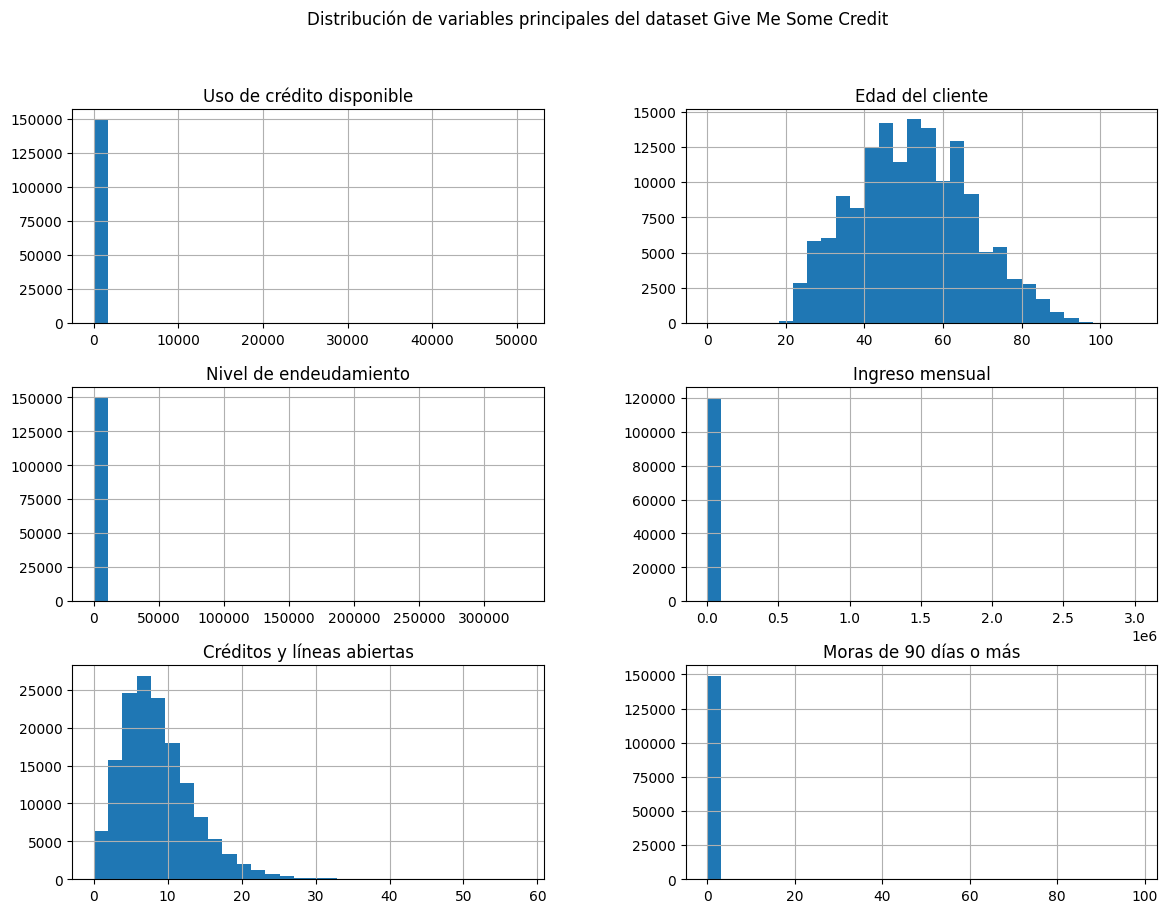

In [34]:
# Selección de variables principales para análisis visual

variables_principales = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate"
]

# Para la presentación, se renombran las columnas de la gráfica.
df_distribuciones = df[variables_principales].rename(columns=nombres_entendibles)

# Gráficas de distribución

df_distribuciones.hist(figsize=(14, 10), bins=30)

plt.suptitle("Distribución de variables principales del dataset Give Me Some Credit")
plt.show()


Las gráficas permiten observar que algunas variables presentan alta dispersión y posibles valores extremos.  
Esto es común en datos financieros, especialmente en variables como ingreso mensual, relación deuda-ingreso y utilización de crédito.

Esta observación justifica aplicar tratamiento de valores extremos antes del entrenamiento, evitando que unos pocos registros dominen el cálculo de distancias de DBSCAN.

## 5.3 Análisis de correlaciones

Se analiza la relación entre las variables numéricas del dataset mediante un mapa de calor.  
Esto ayuda a identificar variables que tienen comportamientos similares o relaciones fuertes entre sí.

La variable `SeriousDlqin2yrs` se incluye en este análisis solo como referencia descriptiva, pero no se utilizará para entrenar DBSCAN.

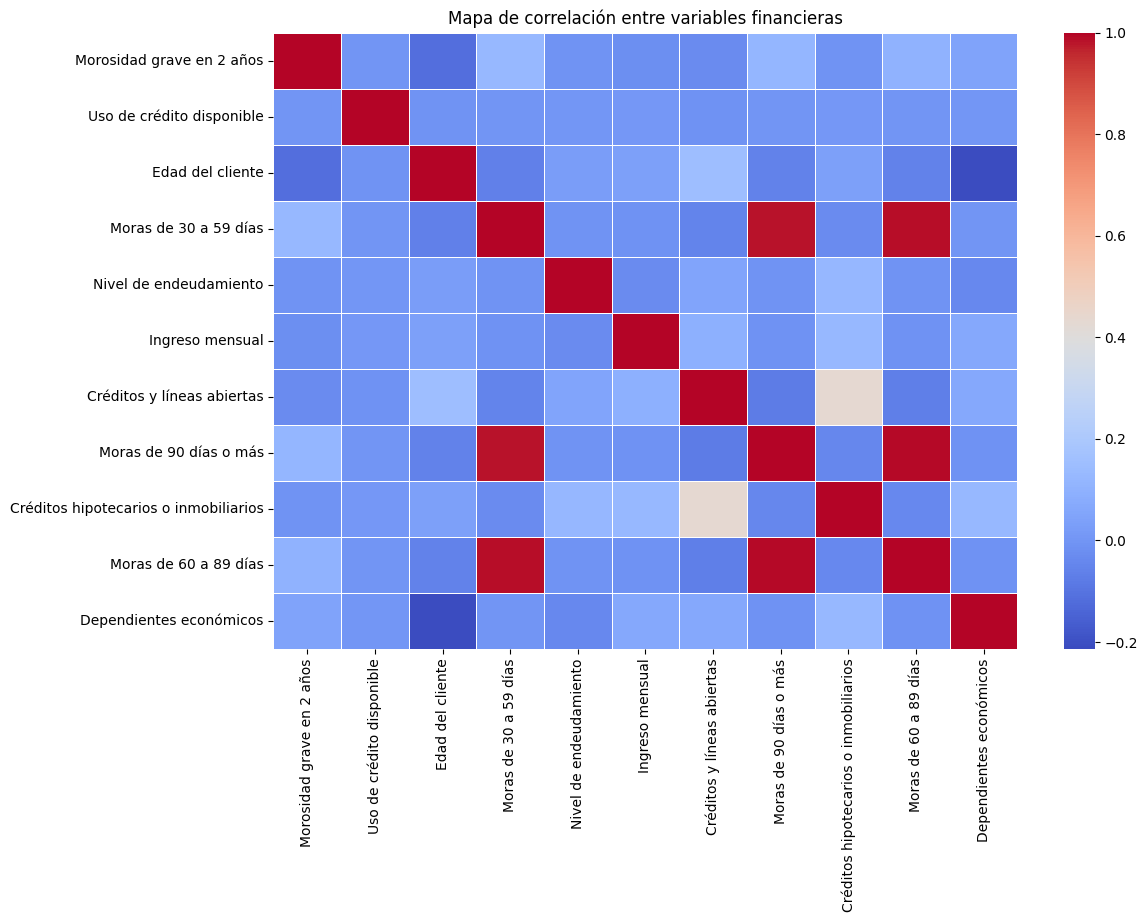

In [35]:
# Mapa de calor de correlaciones

# Se elimina la columna identificadora si existe.
df_correlacion = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Se renombran columnas para que el mapa sea más entendible en la presentación.
df_correlacion = df_correlacion.rename(columns=nombres_entendibles)

plt.figure(figsize=(12, 8))

correlacion = df_correlacion.corr(numeric_only=True)

sns.heatmap(
    correlacion,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Mapa de correlación entre variables financieras")
plt.show()


El mapa de correlación permite identificar relaciones entre variables del comportamiento financiero de los clientes.  
Por ejemplo, las variables relacionadas con retrasos en pagos pueden presentar asociación entre sí, ya que todas representan señales de incumplimiento o mora.

Este análisis es útil para comprender la estructura general de los datos antes de aplicar DBSCAN. Sin embargo, el entrenamiento del modelo se realiza sin usar la variable `SeriousDlqin2yrs` como etiqueta, ya que el enfoque del proyecto es no supervisado.

## 5.4 Análisis visual de outliers

Se realiza una revisión visual de posibles valores atípicos mediante diagramas de caja.  
Este análisis es relevante porque DBSCAN puede identificar registros atípicos como ruido, representados con la etiqueta `-1`.

En este proyecto, los outliers no se eliminan automáticamente. Se tratan mediante límites razonables para reducir distorsiones, pero se conserva la posibilidad de que DBSCAN identifique clientes atípicos.

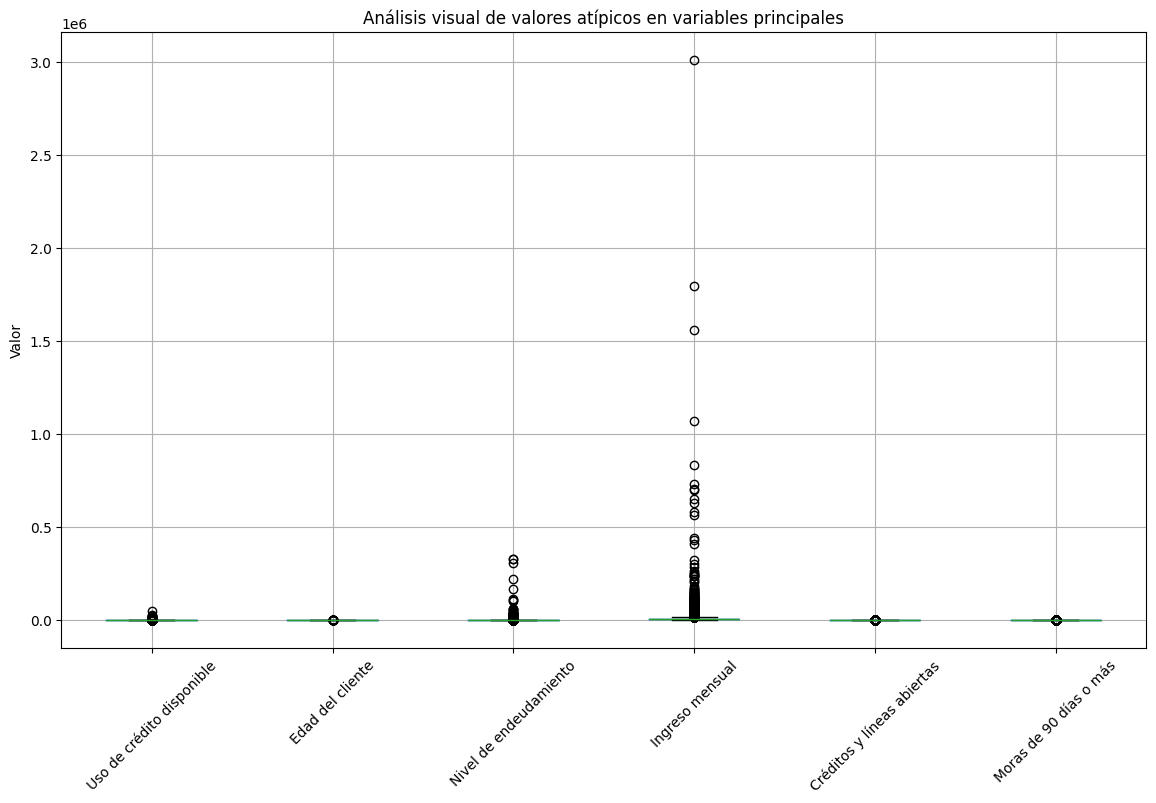

In [36]:
# Visualización de posibles outliers en variables principales

plt.figure(figsize=(14, 8))

df[variables_principales].rename(columns=nombres_entendibles).boxplot()

plt.title("Análisis visual de valores atípicos en variables principales")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


En los diagramas de caja se pueden observar posibles valores atípicos en algunas variables financieras.  
Estos valores son relevantes para el negocio porque pueden representar clientes con comportamientos poco comunes, como utilización excesiva de crédito, alto endeudamiento o historial de mora.

Para evitar que valores extremos afecten de forma excesiva el cálculo de distancias, se aplicará clipping por percentiles en el preprocesamiento.

## 5.5 Conclusión del EDA

A partir del análisis exploratorio se identificó que el dataset contiene variables numéricas relacionadas con riesgo crediticio, endeudamiento, historial de pago y capacidad financiera.

También se observaron valores nulos en algunas columnas, por lo que será necesario aplicar una estrategia de limpieza. Además, varias variables presentan alta dispersión y posibles valores atípicos, lo cual justifica el uso de DBSCAN como algoritmo de clustering y detección de ruido.

Debido a que las variables tienen diferentes escalas, será necesario aplicar estandarización antes del entrenamiento del modelo. Además, se usará la variable `SeriousDlqin2yrs` únicamente como referencia para interpretar si los clusters concentran mayor o menor riesgo.

## 6. Preprocesamiento de datos

Para entrenar DBSCAN se realiza una limpieza orientada a un caso real de riesgo crediticio:

1. Eliminar `Unnamed: 0` porque es un identificador y no aporta al agrupamiento.
2. Separar `SeriousDlqin2yrs` como variable de referencia, sin usarla para entrenar.
3. Seleccionar variables financieras relevantes.
4. Rellenar valores nulos con la mediana.
5. Tratar valores extremos mediante clipping por percentiles.
6. Tomar una muestra controlada para que DBSCAN sea eficiente.
7. Escalar los datos con `StandardScaler`.

El escalado es muy importante porque DBSCAN trabaja con distancias. Si las variables tienen escalas muy diferentes, el algoritmo puede dar más importancia a columnas con valores grandes como `MonthlyIncome` o `DebtRatio`.

In [37]:
# Se crea una copia del dataset para el procesamiento.
df_model = df.copy()

# Se elimina la columna identificadora si existe.
df_model = df_model.drop(columns=["Unnamed: 0"], errors="ignore")

# La variable SeriousDlqin2yrs se conserva como referencia para interpretar clusters.
# No se utiliza para entrenar DBSCAN porque el algoritmo es no supervisado.
y_referencia = df_model["SeriousDlqin2yrs"].copy() if "SeriousDlqin2yrs" in df_model.columns else None
df_model = df_model.drop(columns=["SeriousDlqin2yrs"], errors="ignore")

# Selección de variables financieras relevantes para clustering.
columnas_modelo = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents"
]

df_model = df_model[columnas_modelo]

# Se rellenan valores nulos con la mediana de cada columna.
df_model = df_model.fillna(df_model.median(numeric_only=True))

# Tratamiento de valores extremos mediante clipping.
# Se limitan valores muy extremos entre percentiles 1 y 99 para reducir distorsiones.
for columna in df_model.columns:
    limite_inferior = df_model[columna].quantile(0.01)
    limite_superior = df_model[columna].quantile(0.99)
    df_model[columna] = df_model[columna].clip(limite_inferior, limite_superior)

# DBSCAN puede ser costoso con datasets muy grandes.
# Se usa una muestra reproducible que supera el mínimo requerido por la guía.
tamano_muestra = min(10000, len(df_model))
df_model = df_model.sample(n=tamano_muestra, random_state=42)

# Se alinea la variable de referencia con la muestra seleccionada.
if y_referencia is not None:
    y_referencia = y_referencia.loc[df_model.index]

# Se valida que no queden valores nulos.
print("Total de valores nulos después de limpieza:", df_model.isnull().sum().sum())
print("Dimensiones del dataset para entrenamiento:", df_model.shape)

# Se muestran las primeras filas del dataset procesado con nombres entendibles.
df_model.rename(columns=nombres_entendibles).head()

Total de valores nulos después de limpieza: 0
Dimensiones del dataset para entrenamiento: (10000, 10)


,Uso de crédito disponible,Edad del cliente,Moras de 30 a 59 días,Nivel de endeudamiento,Ingreso mensual,Créditos y líneas abiertas,Moras de 90 días o más,Créditos hipotecarios o inmobiliarios,Moras de 60 a 89 días,Dependientes económicos
59770,0.029690,57,0,0.283244,10121.0,7,0,1,0,0.0
21362,0.000000,57,0,0.142562,7750.0,9,0,1,0,0.0
127324,0.036569,48,0,0.236294,6000.0,6,0,2,0,3.0
140509,1.018331,41,0,0.163138,4958.0,4,0,0,0,0.0
144297,1.008799,49,0,3942.000000,5400.0,10,0,1,0,0.0


In [38]:
# Guardar dataset procesado para evidenciar el avance del proyecto.

ruta_dataset_procesado = "../data/processed/give_me_some_credit_processed.csv"

df_model.to_csv(ruta_dataset_procesado, index=False)

print("Dataset procesado guardado en:", ruta_dataset_procesado)

Dataset procesado guardado en: ../data/processed/give_me_some_credit_processed.csv


In [39]:
# Escalado de datos.
# StandardScaler transforma las variables para que tengan media 0 y desviación estándar 1.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

print("Datos escalados correctamente.")
print("Forma de X_scaled:", X_scaled.shape)

Datos escalados correctamente.
Forma de X_scaled: (10000, 10)


## 7. Entrenamiento del modelo DBSCAN

En esta sección se entrena el modelo DBSCAN usando la implementación de `scikit-learn`.

Para evitar un resultado con demasiados clusters difíciles de explicar, se realiza una búsqueda sencilla de parámetros `eps` y `min_samples`. El objetivo es encontrar una configuración que genere una segmentación útil para negocio, preferiblemente entre 2 y 6 clusters válidos, además de clientes atípicos.

Este ajuste es importante porque la aplicación final no debe mostrar únicamente “Cluster 0”, sino una interpretación comprensible para el usuario final.

In [40]:
# Entrenamiento del modelo DBSCAN.
# Se prueban varias combinaciones para evitar una segmentación con demasiados clusters.

parametros = [
    (0.8, 10),
    (1.0, 10),
    (1.2, 10),
    (1.5, 10),
    (1.8, 10),
    (2.0, 10),
    (1.2, 20),
    (1.5, 20),
    (1.8, 20),
    (2.0, 20),
    (2.5, 20)
]

resultados_parametros = []

for eps, min_samples in parametros:
    modelo_prueba = DBSCAN(eps=eps, min_samples=min_samples)
    labels_prueba = modelo_prueba.fit_predict(X_scaled)

    clusters_prueba = len(set(labels_prueba)) - (1 if -1 in labels_prueba else 0)
    atipicos_prueba = list(labels_prueba).count(-1)
    porcentaje_atipicos_prueba = (atipicos_prueba / len(labels_prueba)) * 100

    # Se calcula Silhouette únicamente si hay al menos dos clusters válidos.
    mascara_valida = labels_prueba != -1
    if len(set(labels_prueba[mascara_valida])) > 1:
        sil_prueba = silhouette_score(X_scaled[mascara_valida], labels_prueba[mascara_valida])
    else:
        sil_prueba = np.nan

    resultados_parametros.append({
        "eps": eps,
        "min_samples": min_samples,
        "clusters": clusters_prueba,
        "atipicos": atipicos_prueba,
        "porcentaje_atipicos": porcentaje_atipicos_prueba,
        "silhouette": sil_prueba
    })

df_parametros = pd.DataFrame(resultados_parametros)
display(df_parametros)

# Selección de una configuración fácil de explicar: entre 2 y 6 clusters válidos.
candidatos = df_parametros[
    (df_parametros["clusters"] >= 2) &
    (df_parametros["clusters"] <= 6) &
    (df_parametros["porcentaje_atipicos"] <= 50)
].copy()

if not candidatos.empty:
    mejor_config = candidatos.sort_values(by="silhouette", ascending=False).iloc[0]
else:
    # Si no hay candidato ideal, se toma la configuración con cantidad de clusters más cercana a 4.
    df_parametros["distancia_objetivo"] = abs(df_parametros["clusters"] - 4)
    mejor_config = df_parametros.sort_values(by=["distancia_objetivo", "porcentaje_atipicos"]).iloc[0]

eps_final = float(mejor_config["eps"])
min_samples_final = int(mejor_config["min_samples"])

print("Parámetros seleccionados:")
print("eps:", eps_final)
print("min_samples:", min_samples_final)

dbscan_model = DBSCAN(
    eps=eps_final,
    min_samples=min_samples_final
)

# fit_predict entrena el modelo y asigna una etiqueta de cluster a cada cliente.
labels = dbscan_model.fit_predict(X_scaled)

# Se agrega la etiqueta del cluster al dataset procesado.
df_resultado = df_model.copy()
df_resultado["Cluster"] = labels

# Se agrega la variable de referencia para interpretar los clusters.
if y_referencia is not None:
    df_resultado["SeriousDlqin2yrs"] = y_referencia.values

print("Modelo DBSCAN entrenado correctamente.")
print("Primeras etiquetas generadas:")
print(labels[:20])

,eps,min_samples,clusters,atipicos,porcentaje_atipicos,silhouette
0,0.8,10,22,4007,40.07,-0.038151
1,1.0,10,12,2971,29.71,-0.033337
2,1.2,10,6,1910,19.10,0.065305
3,1.5,10,12,1073,10.73,0.050671
4,1.8,10,7,612,6.12,0.199613
5,2.0,10,9,426,4.26,0.201877
6,1.2,20,3,2451,24.51,0.071541
7,1.5,20,5,1452,14.52,0.069615
8,1.8,20,4,877,8.77,0.198761
9,2.0,20,4,630,6.30,0.201153


Parámetros seleccionados:
eps: 2.0
min_samples: 20
Modelo DBSCAN entrenado correctamente.
Primeras etiquetas generadas:
[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]


In [41]:
# Conteo de clientes por cluster.

conteo_clusters = df_resultado["Cluster"].value_counts().sort_index()

print("Cantidad de registros por cluster:")
print(conteo_clusters)

Cantidad de registros por cluster:
Cluster
-1     630
 0    9016
 1     174
 2     160
 3      20
Name: count, dtype: int64


## 8. Evaluación del modelo

Como DBSCAN es un algoritmo no supervisado, no se evalúa con accuracy, precisión o recall. En su lugar, se revisan métricas de agrupamiento y comportamiento de los clusters.

Se calculan:

- **Cantidad de clusters encontrados**
- **Cantidad de clientes atípicos**
- **Porcentaje de clientes atípicos**
- **Silhouette Score**
- **Davies-Bouldin Score**
- **Tasa de morosidad grave por cluster** usando `SeriousDlqin2yrs` como referencia de negocio

Para evitar distorsiones, las métricas de clustering se calculan sobre los puntos que no fueron marcados como ruido.

In [42]:
# Cálculo de métricas generales del modelo.

cantidad_clusters = len(set(labels)) - (1 if -1 in labels else 0)
cantidad_atipicos = list(labels).count(-1)
porcentaje_atipicos = (cantidad_atipicos / len(labels)) * 100

print("Cantidad de clusters encontrados:", cantidad_clusters)
print("Cantidad de clientes atípicos:", cantidad_atipicos)
print("Porcentaje de clientes atípicos:", round(porcentaje_atipicos, 2), "%")

# Para calcular métricas de clustering se excluyen los registros marcados como ruido.
mascara_sin_ruido = labels != -1
labels_sin_ruido = labels[mascara_sin_ruido]
X_sin_ruido = X_scaled[mascara_sin_ruido]

# Validación para evitar errores si el modelo solo encuentra un cluster.
if len(set(labels_sin_ruido)) > 1:
    silhouette = silhouette_score(X_sin_ruido, labels_sin_ruido)
    davies_bouldin = davies_bouldin_score(X_sin_ruido, labels_sin_ruido)

    print("Silhouette Score:", round(silhouette, 4))
    print("Davies-Bouldin Score:", round(davies_bouldin, 4))
else:
    silhouette = None
    davies_bouldin = None

    print("No se calcularon Silhouette Score ni Davies-Bouldin Score.")
    print("Motivo: DBSCAN encontró menos de dos clusters válidos sin contar el ruido.")

# Interpretación de negocio usando la variable de referencia.
if "SeriousDlqin2yrs" in df_resultado.columns:
    perfil_clusters = df_resultado.groupby("Cluster").agg(
        registros=("Cluster", "count"),
        tasa_morosidad_grave=("SeriousDlqin2yrs", "mean"),
        edad_promedio=("age", "mean"),
        ingreso_promedio=("MonthlyIncome", "mean"),
        deuda_promedio=("DebtRatio", "mean"),
        utilizacion_credito_promedio=("RevolvingUtilizationOfUnsecuredLines", "mean"),
        moras_90_dias_promedio=("NumberOfTimes90DaysLate", "mean")
    ).reset_index()

    def interpretar_cluster(fila):
        if fila["Cluster"] == -1:
            return "Cliente atípico: requiere revisión manual"
        elif fila["tasa_morosidad_grave"] <= 0.05:
            return "Perfil viable: riesgo bajo"
        elif fila["tasa_morosidad_grave"] <= 0.12:
            return "Perfil con riesgo moderado"
        else:
            return "Perfil de alto riesgo"

    perfil_clusters["interpretacion_negocio"] = perfil_clusters.apply(interpretar_cluster, axis=1)

    # Se crea una versión con nombres claros para presentar los resultados.
    perfil_clusters_presentacion = perfil_clusters.rename(columns={
        "registros": "Cantidad de clientes",
        "tasa_morosidad_grave": "Tasa de morosidad grave",
        "edad_promedio": "Edad promedio",
        "ingreso_promedio": "Ingreso promedio",
        "deuda_promedio": "Nivel de endeudamiento promedio",
        "utilizacion_credito_promedio": "Uso de crédito promedio",
        "moras_90_dias_promedio": "Moras de 90 días promedio",
        "interpretacion_negocio": "Interpretación de negocio"
    })

    display(perfil_clusters_presentacion)
else:
    perfil_clusters = None

Cantidad de clusters encontrados: 4
Cantidad de clientes atípicos: 630
Porcentaje de clientes atípicos: 6.3 %


Silhouette Score: 0.2012
Davies-Bouldin Score: 1.2135


,Cluster,Cantidad de clientes,Tasa de morosidad grave,Edad promedio,Ingreso promedio,Nivel de endeudamiento promedio,Uso de crédito promedio,Moras de 90 días promedio,Interpretación de negocio
0,-1,630,0.360317,48.400000,6508.022222,657.096431,0.664499,1.004762,Cliente atípico: requiere revisión manual
1,0,9016,0.038043,52.767192,6193.030280,306.117619,0.287362,0.000000,Perfil viable: riesgo bajo
2,1,174,0.252874,45.425287,4491.787356,39.804079,0.692324,1.000000,Perfil de alto riesgo
3,2,160,0.181250,49.493750,4831.912500,46.053436,0.508524,0.000000,Perfil de alto riesgo
4,3,20,0.550000,35.300000,4137.850000,2.253689,1.000000,3.000000,Perfil de alto riesgo


## 9. Visualización del funcionamiento

El dataset tiene varias variables, por lo cual no se puede graficar directamente en dos dimensiones. Para visualizar los clusters se utiliza **PCA**, una técnica que reduce las variables a dos componentes principales.

Esta visualización no cambia el entrenamiento del modelo. Solo ayuda a observar los grupos encontrados por DBSCAN y a explicar de forma sencilla cómo se distribuyen los perfiles financieros.

In [52]:
print("Estado del Modelo:")
print("- Modelo entrenado: SÍ")
print("- Algoritmo utilizado: DBSCAN")
print("- Dataset utilizado: data/raw/cs-training.csv")
print("- Archivo del modelo serializado: models/dbscan_model.pkl")
print("- Archivo del scaler serializado: models/scaler.pkl")
print("- Archivo de información del modelo: models/model_info.pkl")
print("- Cantidad de clusters encontrados:", cantidad_clusters)
# print("- Cantidad de clientes atípicos:", cantidad_ruido)
# print("- Porcentaje de clientes atípicos:", round((cantidad_ruido / len(labels)) * 100, 2), "%")
print("- Silhouette Score:", silhouette)
print("- Davies-Bouldin Score:", davies_bouldin)
print("- Técnica de preprocesamiento: limpieza de datos, tratamiento de valores nulos, selección de variables financieras y estandarización con StandardScaler.")
print("- Objetivo del modelo: identificar perfiles financieros similares y detectar clientes atípicos que puedan representar un posible riesgo crediticio.")

Estado del Modelo:
- Modelo entrenado: SÍ
- Algoritmo utilizado: DBSCAN
- Dataset utilizado: data/raw/cs-training.csv
- Archivo del modelo serializado: models/dbscan_model.pkl
- Archivo del scaler serializado: models/scaler.pkl
- Archivo de información del modelo: models/model_info.pkl
- Cantidad de clusters encontrados: 4
- Silhouette Score: 0.20115297421670555
- Davies-Bouldin Score: 1.2134950069446335
- Técnica de preprocesamiento: limpieza de datos, tratamiento de valores nulos, selección de variables financieras y estandarización con StandardScaler.
- Objetivo del modelo: identificar perfiles financieros similares y detectar clientes atípicos que puedan representar un posible riesgo crediticio.


In [43]:
# Reducción de dimensionalidad con PCA para visualizar los clusters en 2D.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_visual = pd.DataFrame({
    "PCA_1": X_pca[:, 0],
    "PCA_2": X_pca[:, 1],
    "Cluster": labels
})

df_visual.head()

,PCA_1,PCA_2,Cluster
0,-0.901001,-0.389507,0
1,-0.912488,-0.479082,0
2,-0.619039,0.617381,0
3,1.488549,-1.083015,0
4,0.152350,0.355040,0


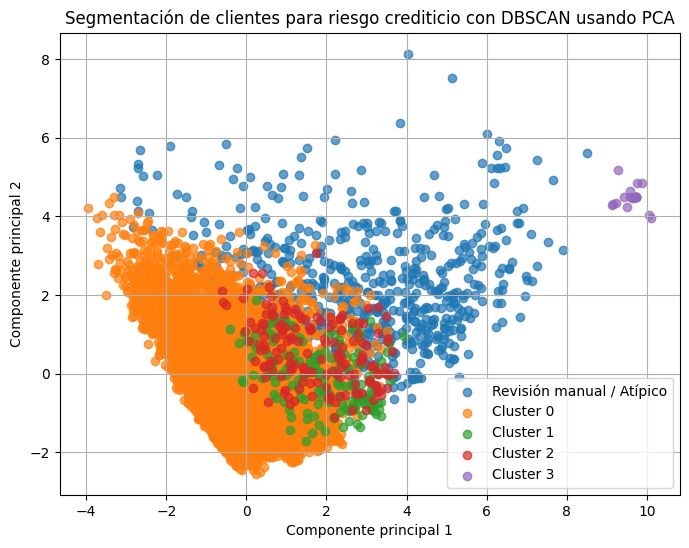

In [44]:
# Gráfica de clusters generados por DBSCAN.
# Cada punto representa un cliente.
# La etiqueta -1 representa clientes atípicos.

plt.figure(figsize=(8, 6))

for cluster in sorted(df_visual["Cluster"].unique()):
    datos_cluster = df_visual[df_visual["Cluster"] == cluster]
    etiqueta = "Revisión manual / Atípico" if cluster == -1 else f"Cluster {cluster}"

    plt.scatter(
        datos_cluster["PCA_1"],
        datos_cluster["PCA_2"],
        label=etiqueta,
        alpha=0.7
    )

plt.title("Segmentación de clientes para riesgo crediticio con DBSCAN usando PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.grid(True)
plt.show()

### Interpretación de la visualización

La gráfica permite observar cómo DBSCAN separa los clientes en diferentes grupos según la densidad de sus perfiles financieros.

**Convenciones:**

- Los clusters numerados representan grupos de clientes con características financieras similares.
- La etiqueta **-1** representa clientes atípicos o casos que requieren revisión manual.
- La visualización usa PCA, por lo tanto, es una representación reducida del comportamiento real del modelo.

Para el usuario final, el resultado no se interpreta solamente como “Cluster 0” o “Cluster 1”. Cada cluster se traduce a una conclusión de negocio usando variables como morosidad, deuda, ingreso, edad y utilización de crédito. De esta forma, el modelo puede apoyar decisiones como análisis de riesgo, viabilidad financiera o revisión manual.

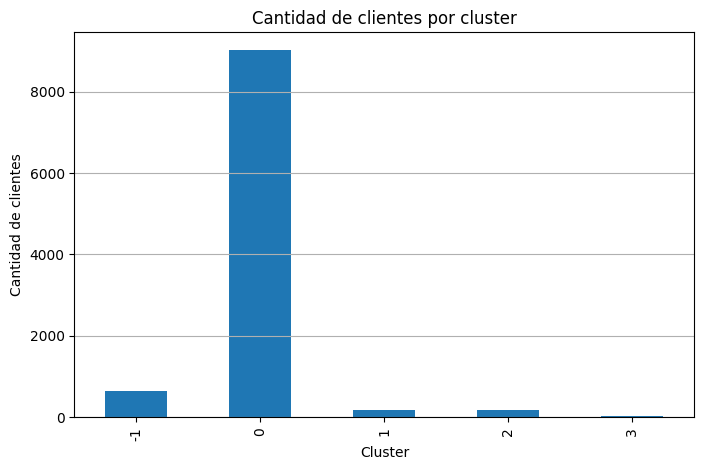

In [45]:
# Gráfica de barras con la cantidad de clientes por cluster.

plt.figure(figsize=(8, 5))
conteo_clusters.plot(kind="bar")

plt.title("Cantidad de clientes por cluster")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de clientes")
plt.grid(axis="y")
plt.show()

## 10. Serialización del modelo

Para cumplir con la entrega, se deben guardar los archivos entrenados en la carpeta `models/`.

Se guardan tres archivos:

```text
models/dbscan_model.pkl
models/scaler.pkl
models/model_info.pkl
```

El archivo `dbscan_model.pkl` contiene el modelo DBSCAN entrenado.  
El archivo `scaler.pkl` contiene el escalador usado antes del entrenamiento.  
El archivo `model_info.pkl` contiene información útil para documentar los resultados, incluyendo columnas utilizadas, parámetros, métricas y perfiles de negocio por cluster.

In [46]:
# Serialización del modelo DBSCAN, el scaler y la información del modelo.

ruta_modelo = "../models/dbscan_model.pkl"
ruta_scaler = "../models/scaler.pkl"
ruta_info = "../models/model_info.pkl"

joblib.dump(dbscan_model, ruta_modelo)
joblib.dump(scaler, ruta_scaler)

if perfil_clusters is not None:
    perfiles_serializables = perfil_clusters.to_dict(orient="records")
else:
    perfiles_serializables = None

model_info = {
    "algorithm": "DBSCAN",
    "dataset": "Give Me Some Credit",
    "source": "Kaggle - https://www.kaggle.com/c/GiveMeSomeCredit",
    "source_file": "data/raw/cs-training.csv",
    "processed_file": "data/processed/give_me_some_credit_processed.csv",
    "columns": list(df_model.columns),
    "column_descriptions": nombres_entendibles,
    "target_reference": "SeriousDlqin2yrs",
    "target_used_for_training": False,
    "eps": dbscan_model.eps,
    "min_samples": dbscan_model.min_samples,
    "clusters": cantidad_clusters,
    "outliers": cantidad_atipicos,
    "outlier_percentage": porcentaje_atipicos,
    "silhouette_score": silhouette,
    "davies_bouldin_score": davies_bouldin,
    "business_profiles": perfiles_serializables
}

joblib.dump(model_info, ruta_info)

print("Modelo guardado en:", ruta_modelo)
print("Scaler guardado en:", ruta_scaler)
print("Información del modelo guardada en:", ruta_info)

Modelo guardado en: ../models/dbscan_model.pkl
Scaler guardado en: ../models/scaler.pkl
Información del modelo guardada en: ../models/model_info.pkl


In [ ]:
# Validación de carga de los archivos serializados.

modelo_cargado = joblib.load("../models/dbscan_model.pkl")
scaler_cargado = joblib.load("../models/scaler.pkl")
info_cargada = joblib.load("../models/model_info.pkl")

print("Modelo cargado:", type(modelo_cargado))
print("Scaler cargado:", type(scaler_cargado))
print("Información cargada:")
print(info_cargada)

Modelo cargado: <class 'sklearn.cluster._dbscan.DBSCAN'>
Scaler cargado: <class 'sklearn.preprocessing._data.StandardScaler'>
Información cargada:
{'algorithm': 'DBSCAN', 'dataset': 'Give Me Some Credit', 'source': 'Kaggle - https://www.kaggle.com/c/GiveMeSomeCredit', 'source_file': 'data/raw/cs-training.csv', 'processed_file': 'data/processed/give_me_some_credit_processed.csv', 'columns': ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents'], 'column_descriptions': {'Unnamed: 0': 'Identificador', 'SeriousDlqin2yrs': 'Morosidad grave en 2 años', 'RevolvingUtilizationOfUnsecuredLines': 'Uso de crédito disponible', 'age': 'Edad del cliente', 'NumberOfTime30-59DaysPastDueNotWorse': 'Moras de 30 a 59 días', 'DebtRatio': 'Nivel de endeudamiento', 'MonthlyIncome': 'Ingreso me

Estado del Modelo:
- Modelo entrenado: SÍ
- Algoritmo utilizado: DBSCAN
- Dataset utilizado: data/raw/cs-training.csv
- Archivo del modelo serializado: models/dbscan_model.pkl
- Archivo del scaler serializado: models/scaler.pkl
- Archivo de información del modelo: models/model_info.pkl
- Cantidad de clusters encontrados: 4


NameError: name 'cantidad_ruido' is not defined

In [48]:
# Validaciones finales del proceso.

print("Validación 1 - Dataset original cargado:", df.shape[0] > 0)
print("Validación 2 - Sin nulos en datos procesados:", df_model.isnull().sum().sum() == 0)
print("Validación 3 - Datos escalados:", X_scaled.shape[0] == df_model.shape[0])
print("Validación 4 - Etiquetas generadas:", len(labels) == df_model.shape[0])
print("Validación 5 - Archivo modelo existe:", os.path.exists("../models/dbscan_model.pkl"))
print("Validación 6 - Archivo scaler existe:", os.path.exists("../models/scaler.pkl"))
print("Validación 7 - Archivo info existe:", os.path.exists("../models/model_info.pkl"))
print("Validación 8 - Variable de referencia no usada para entrenamiento:", "SeriousDlqin2yrs" not in df_model.columns)

Validación 1 - Dataset original cargado: True
Validación 2 - Sin nulos en datos procesados: True
Validación 3 - Datos escalados: True
Validación 4 - Etiquetas generadas: True
Validación 5 - Archivo modelo existe: True
Validación 6 - Archivo scaler existe: True
Validación 7 - Archivo info existe: True
Validación 8 - Variable de referencia no usada para entrenamiento: True


## 12. Interpretación de resultados

Los resultados del modelo permiten analizar perfiles financieros de clientes para apoyar decisiones de riesgo crediticio.

La cantidad de clusters encontrados indica cuántos grupos de comportamiento financiero fueron identificados. Cada cluster puede representar un perfil diferente, por ejemplo:

- Clientes viables o de bajo riesgo.
- Clientes con riesgo moderado.
- Clientes con mayor probabilidad de presentar dificultades financieras.
- Clientes atípicos que requieren revisión manual.

Los clientes marcados con la etiqueta `-1` son considerados atípicos. Esto no significa automáticamente que el cliente deba ser rechazado, sino que su perfil no se parece al de los grupos principales encontrados por el algoritmo. En una entidad financiera, estos casos deberían revisarse con mayor detalle.

La variable `SeriousDlqin2yrs` no fue usada para entrenar DBSCAN. Se utilizó únicamente después del clustering para interpretar los grupos y estimar qué clusters concentran mayor o menor proporción de clientes con morosidad grave. Esto permite traducir el resultado técnico del modelo a una conclusión útil para el usuario final.

## 13. Conclusiones

- Se implementó el algoritmo **DBSCAN** utilizando librerías de Python, específicamente `scikit-learn`.
- Se trabajó con el dataset **Give Me Some Credit**, enfocado en riesgo crediticio y comportamiento financiero.
- El dataset cumple con la guía porque es real, proviene de Kaggle, supera los 500 registros y contiene más de 5 variables relevantes.
- Se realizó limpieza de datos, tratamiento de valores nulos, tratamiento de valores extremos y escalado de variables numéricas.
- DBSCAN permitió segmentar clientes y detectar registros atípicos mediante la etiqueta `-1`.
- Se ajustaron parámetros para evitar una segmentación excesiva con demasiados clusters difíciles de explicar.
- Se incorporó una interpretación de negocio para que el resultado no sea únicamente “Cluster 0”, sino una conclusión como riesgo bajo, riesgo moderado, alto riesgo o revisión manual.
- El modelo fue serializado correctamente en la carpeta `models/`.
- También se guardó el `StandardScaler`, ya que es necesario para aplicar el mismo preprocesamiento en la aplicación.
- El notebook cumple con los componentes requeridos para avanzar hacia la entrega final: modelo entrenado, serialización, evaluación e interpretación de resultados.

## 14. Referencias

- Kaggle. Give Me Some Credit.  
  https://www.kaggle.com/c/GiveMeSomeCredit

- Scikit-learn. DBSCAN Clustering.  
  https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

- Scikit-learn. StandardScaler.  
  https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

- Scikit-learn. Clustering performance evaluation.  
  https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation

- Scikit-learn. PCA.  
  https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html